### Installation

In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

### Unsloth

In [2]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 2048 # Choose any! We auto support RoPE Scaling internally!
dtype = None # None for auto detection. Float16 for Tesla T4, V100, Bfloat16 for Ampere+
load_in_4bit = True # Use 4bit quantization to reduce memory usage. Can be False.

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Llama-3.2-3B-Instruct", # or choose "unsloth/Llama-3.2-1B-Instruct"
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
    # token = "YOUR_HF_TOKEN", # HF Token for gated models
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.6: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

We now add LoRA adapters so we only need to update 1 to 10% of all parameters!

In [3]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    # [NEW] "unsloth" uses 30% less VRAM, fits 2x larger batch sizes!
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for very long context
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
)

Unsloth 2026.4.6 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


<a name="Data"></a>
### Data Prep
We now use the `Llama-3.1` format for conversation style finetunes. We use [Maxime Labonne's FineTome-100k](https://huggingface.co/datasets/mlabonne/FineTome-100k) dataset in ShareGPT style. But we convert it to HuggingFace's normal multiturn format `("role", "content")` instead of `("from", "value")`/ Llama-3 renders multi turn conversations like below:

```
<|begin_of_text|><|start_header_id|>user<|end_header_id|>

Hello!<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Hey there! How are you?<|eot_id|><|start_header_id|>user<|end_header_id|>

I'm great thanks!<|eot_id|>
```

We use our `get_chat_template` function to get the correct chat template. We support `zephyr, chatml, mistral, llama, alpaca, vicuna, vicuna_old, phi3, llama3` and more.

In [4]:
from unsloth.chat_templates import get_chat_template

tokenizer = get_chat_template(
    tokenizer,
    chat_template = "llama-3.1",
)

def formatting_prompts_func(examples):
    convos = examples["conversations"]
    texts = [tokenizer.apply_chat_template(convo, tokenize = False, add_generation_prompt = False) for convo in convos]
    return { "text" : texts, }

from datasets import load_dataset
dataset = load_dataset("mlabonne/FineTome-100k", split = "train")

README.md:   0%|          | 0.00/982 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

We now use `standardize_sharegpt` to convert ShareGPT style datasets into HuggingFace's generic format. This changes the dataset from looking like:
```
{"from": "system", "value": "You are an assistant"}
{"from": "human", "value": "What is 2+2?"}
{"from": "gpt", "value": "It's 4."}
```
to
```
{"role": "system", "content": "You are an assistant"}
{"role": "user", "content": "What is 2+2?"}
{"role": "assistant", "content": "It's 4."}
```

In [5]:
from unsloth.chat_templates import standardize_sharegpt
dataset = standardize_sharegpt(dataset)
dataset = dataset.map(formatting_prompts_func, batched = True,)

Unsloth: Standardizing formats (num_proc=6):   0%|          | 0/100000 [00:00<?, ? examples/s]

Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

We look at how the conversations are structured for item 5:

In [6]:
dataset[5]["conversations"]

[{'content': 'How do astronomers determine the original wavelength of light emitted by a celestial body at rest, which is necessary for measuring its speed using the Doppler effect?',
  'role': 'user'},
 {'content': 'Astronomers make use of the unique spectral fingerprints of elements found in stars. These elements emit and absorb light at specific, known wavelengths, forming an absorption spectrum. By analyzing the light received from distant stars and comparing it to the laboratory-measured spectra of these elements, astronomers can identify the shifts in these wavelengths due to the Doppler effect. The observed shift tells them the extent to which the light has been redshifted or blueshifted, thereby allowing them to calculate the speed of the star along the line of sight relative to Earth.',
  'role': 'assistant'}]

And we see how the chat template transformed these conversations.

**[Notice]** Llama 3.1 Instruct's default chat template default adds `"Cutting Knowledge Date: December 2023\nToday Date: 26 July 2024"`, so do not be alarmed!

In [7]:
dataset[5]["text"]

'<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 July 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nHow do astronomers determine the original wavelength of light emitted by a celestial body at rest, which is necessary for measuring its speed using the Doppler effect?<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nAstronomers make use of the unique spectral fingerprints of elements found in stars. These elements emit and absorb light at specific, known wavelengths, forming an absorption spectrum. By analyzing the light received from distant stars and comparing it to the laboratory-measured spectra of these elements, astronomers can identify the shifts in these wavelengths due to the Doppler effect. The observed shift tells them the extent to which the light has been redshifted or blueshifted, thereby allowing them to calculate the speed of the star along the line of sight relative to Earth.<|

<a name="Train"></a>
### Train the model
Now let's train our model. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`. We also support `DPOTrainer` and `GRPOTrainer` for reinforcement learning!!

In [8]:
from trl import SFTConfig, SFTTrainer
from transformers import DataCollatorForSeq2Seq
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    data_collator = DataCollatorForSeq2Seq(tokenizer = tokenizer),
    packing = False, # Can make training 5x faster for short sequences.
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        # num_train_epochs = 1, # Set this for 1 full training run.
        max_steps = 60,
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none", # Use TrackIO/WandB etc
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/100000 [00:00<?, ? examples/s]

We also use Unsloth's `train_on_completions` method to only train on the assistant outputs and ignore the loss on the user's inputs.

In [9]:
from unsloth.chat_templates import train_on_responses_only
trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|start_header_id|>user<|end_header_id|>\n\n",
    response_part = "<|start_header_id|>assistant<|end_header_id|>\n\n",
)

Map (num_proc=6):   0%|          | 0/100000 [00:00<?, ? examples/s]

Filter (num_proc=6):   0%|          | 0/100000 [00:00<?, ? examples/s]

Unsloth: Removed 93 out of 100000 samples from train_dataset where all labels were -100 (no response found after truncation). This prevents NaN loss during training.


We verify masking is actually done:

In [10]:
tokenizer.decode(trainer.train_dataset[5]["input_ids"])

'<|begin_of_text|><|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 July 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nHow do astronomers determine the original wavelength of light emitted by a celestial body at rest, which is necessary for measuring its speed using the Doppler effect?<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nAstronomers make use of the unique spectral fingerprints of elements found in stars. These elements emit and absorb light at specific, known wavelengths, forming an absorption spectrum. By analyzing the light received from distant stars and comparing it to the laboratory-measured spectra of these elements, astronomers can identify the shifts in these wavelengths due to the Doppler effect. The observed shift tells them the extent to which the light has been redshifted or blueshifted, thereby allowing them to calculate the speed of the star along the line of sight rel

In [11]:
space = tokenizer(" ", add_special_tokens = False).input_ids[0]
tokenizer.decode([space if x == -100 else x for x in trainer.train_dataset[5]["labels"]])

'                                                                  Astronomers make use of the unique spectral fingerprints of elements found in stars. These elements emit and absorb light at specific, known wavelengths, forming an absorption spectrum. By analyzing the light received from distant stars and comparing it to the laboratory-measured spectra of these elements, astronomers can identify the shifts in these wavelengths due to the Doppler effect. The observed shift tells them the extent to which the light has been redshifted or blueshifted, thereby allowing them to calculate the speed of the star along the line of sight relative to Earth.<|eot_id|>'

We can see the System and Instruction prompts are successfully masked!

In [12]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.563 GB.
3.051 GB of memory reserved.


In [13]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 99,907 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,0.755600
2,0.930600
3,0.873500
4,0.542300
5,0.860100
6,1.058500
7,0.849600
8,0.801700
9,0.722900
10,0.818200


In [14]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

450.5013 seconds used for training.
7.51 minutes used for training.
Peak reserved memory = 5.4 GB.
Peak reserved memory for training = 2.349 GB.
Peak reserved memory % of max memory = 37.08 %.
Peak reserved memory for training % of max memory = 16.13 %.


## 3. Training Configuration

This section documents every hyperparameter used in `SFTConfig` and explains the reasoning behind each choice.

| Parameter | Value | Why |
|---|---|---|
| `per_device_train_batch_size` | 2 | Keeps VRAM low on consumer GPUs with a 3B model in 4-bit |
| `gradient_accumulation_steps` | 4 | Effective batch = 2 × 4 = **8**; simulates larger batch without extra memory |
| `warmup_steps` | 5 | Gradually ramps LR for the first 5 steps to avoid instability |
| `max_steps` | 60 | Quick demo run; replace with `num_train_epochs=1` for a full run |
| `learning_rate` | 2e-4 | Standard LoRA rate; fast enough to learn, low enough to avoid overfitting |
| `optim` | adamw_8bit | 8-bit Adam saves ~75 % VRAM vs fp32 Adam with negligible accuracy loss |
| `weight_decay` | 0.001 | Light L2 regularisation prevents adapter weights growing too large |
| `lr_scheduler_type` | linear | Linearly decays LR to 0; simple and effective for short runs |
| `max_seq_length` | 2048 | Covers most conversation turns |
| **LoRA rank `r`** | 16 | Balances capacity vs parameter count (8 = lighter, 32 = more expressive) |
| **`lora_alpha`** | 16 | Equal to `r` → scaling factor = 1.0 (neutral) |
| **`lora_dropout`** | 0 | Disabled — Unsloth optimises for dropout=0 |
| **Target modules** | q/k/v/o/gate/up/down | All attention + MLP projections for full transformer fine-tuning |


In [15]:
# ── 3. Training Configuration Summary ──────────────────────────────────────
# Run this cell to print a clean summary of every training hyperparameter.

training_config = {
    # SFTConfig / TrainingArguments
    'per_device_train_batch_size': 2,
    'gradient_accumulation_steps': 4,
    'effective_batch_size': 2 * 4,
    'warmup_steps': 5,
    'max_steps': 60,
    'learning_rate': 2e-4,
    'optimizer': 'adamw_8bit',
    'weight_decay': 0.001,
    'lr_scheduler': 'linear',
    'max_seq_length': 2048,
    'fp_precision': '4-bit quantised (QLoRA)',
    # LoRA adapter
    'lora_rank_r': 16,
    'lora_alpha': 16,
    'lora_dropout': 0,
    'target_modules': ['q_proj','k_proj','v_proj','o_proj',
                       'gate_proj','up_proj','down_proj'],
    'use_gradient_checkpointing': 'unsloth',
    'train_on': 'assistant responses only (user/system masked)',
}

print('=' * 60)
print('       TRAINING CONFIGURATION SUMMARY')
print('=' * 60)
for k, v in training_config.items():
    print(f'  {k:<40} {v}')
print('=' * 60)

# Count trainable vs frozen parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f'\n  Total parameters   : {total_params:,}')
print(f'  Trainable (LoRA)   : {trainable_params:,}  ({100*trainable_params/total_params:.2f} %)')
print(f'  Frozen             : {frozen_params:,}  ({100*frozen_params/total_params:.2f} %)')
print('=' * 60)


       TRAINING CONFIGURATION SUMMARY
  per_device_train_batch_size              2
  gradient_accumulation_steps              4
  effective_batch_size                     8
  warmup_steps                             5
  max_steps                                60
  learning_rate                            0.0002
  optimizer                                adamw_8bit
  weight_decay                             0.001
  lr_scheduler                             linear
  max_seq_length                           2048
  fp_precision                             4-bit quantised (QLoRA)
  lora_rank_r                              16
  lora_alpha                               16
  lora_dropout                             0
  target_modules                           ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
  use_gradient_checkpointing               unsloth
  train_on                                 assistant responses only (user/system masked)

  Total parameters 

## 4. Evaluation

### What we measure
| Metric | Meaning |
|---|---|
| **Training loss** | Cross-entropy on assistant tokens only (lower = better fit) |
| **Perplexity** | `exp(loss)` — how surprised the model is by the data (lower = better) |
| **Before vs After** | Same prompt sent to base model and fine-tuned model for comparison |

> **Note:** Because we use `train_on_responses_only`, loss is computed only on assistant turns — giving a cleaner signal than full-sequence loss.


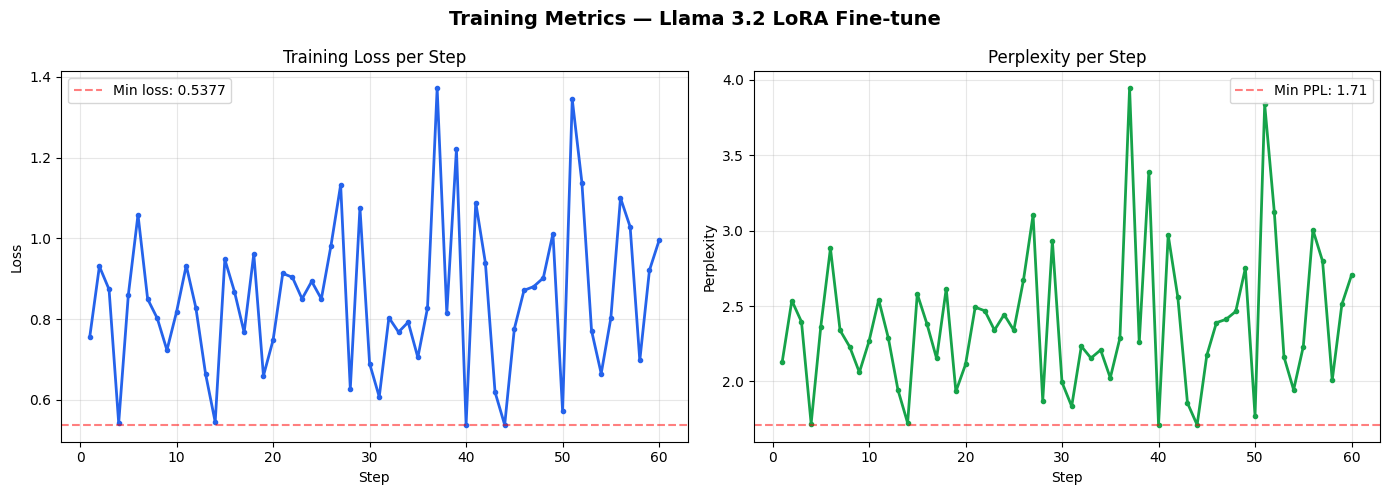


          TRAINING METRICS SUMMARY
  Total steps trained     : 60
  Initial loss (step 1)   : 0.7556  (PPL 2.13)
  Final   loss (last step): 0.9950  (PPL 2.70)
  Loss reduction          : -31.7 %
  Training time           : 450.5s (7.5 min)
  Samples/second          : 1.065


In [16]:
# ── 4a. Training Metrics — Loss & Perplexity Curves ───────────────────────
import matplotlib.pyplot as plt
import math

log_history  = trainer.state.log_history
steps        = [e['step'] for e in log_history if 'loss' in e]
losses       = [e['loss'] for e in log_history if 'loss' in e]
perplexities = [math.exp(l) for l in losses]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Metrics — Llama 3.2 LoRA Fine-tune', fontsize=14, fontweight='bold')

# Loss curve
axes[0].plot(steps, losses, color='#2563eb', linewidth=2, marker='o', markersize=3)
axes[0].set_title('Training Loss per Step')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=min(losses), color='red', linestyle='--', alpha=0.5,
                label=f'Min loss: {min(losses):.4f}')
axes[0].legend()

# Perplexity curve
axes[1].plot(steps, perplexities, color='#16a34a', linewidth=2, marker='o', markersize=3)
axes[1].set_title('Perplexity per Step')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Perplexity')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=min(perplexities), color='red', linestyle='--', alpha=0.5,
                label=f'Min PPL: {min(perplexities):.2f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
initial_loss  = losses[0]
final_loss    = losses[-1]
loss_drop_pct = (initial_loss - final_loss) / initial_loss * 100

print('\n' + '=' * 55)
print('          TRAINING METRICS SUMMARY')
print('=' * 55)
print(f'  Total steps trained     : {steps[-1]}')
print(f'  Initial loss (step 1)   : {initial_loss:.4f}  (PPL {math.exp(initial_loss):.2f})')
print(f'  Final   loss (last step): {final_loss:.4f}  (PPL {math.exp(final_loss):.2f})')
print(f'  Loss reduction          : {loss_drop_pct:.1f} %')
print(f'  Training time           : {trainer_stats.metrics["train_runtime"]:.1f}s '
      f'({trainer_stats.metrics["train_runtime"]/60:.1f} min)')
print(f'  Samples/second          : {trainer_stats.metrics.get("train_samples_per_second", "N/A")}')
print('=' * 55)


In [26]:
# ── 4b. Before vs After Comparison ─────────────────────────────────────────
# Runs the same prompts through the BASE model and the FINE-TUNED model,
# then prints a side-by-side comparison.

import textwrap

TEST_PROMPTS = [
    'Explain what a neural network is in simple terms.',
    'What is the capital of France and what is it famous for?',
    'Write a short Python function to reverse a string.',
]

def generate_response(mdl, tok, prompt, max_new_tokens=150):
    FastLanguageModel.for_inference(mdl)
    msgs   = [{'role': 'user', 'content': prompt}]
    inputs = tok.apply_chat_template(
        msgs, tokenize=True, add_generation_prompt=True, return_tensors='pt'
    ).to('cuda')
    with torch.no_grad():
        out = mdl.generate(
            input_ids=inputs, max_new_tokens=max_new_tokens,
            use_cache=True, temperature=1.5, min_p=0.1,
        )
    new_tokens = out[0][inputs.shape[-1]:]
    return tok.decode(new_tokens, skip_special_tokens=True).strip()

COL = 58
print('=' * (COL * 2 + 4))
print('  BEFORE vs AFTER FINE-TUNING')
print('=' * (COL * 2 + 4))

for i, prompt in enumerate(TEST_PROMPTS, 1):
    print(f'\n[Prompt {i}] {prompt}')
    print('-' * (COL * 2 + 4))

    # After: fine-tuned (LoRA enabled)
    after_response = generate_response(model, tokenizer, prompt)

    # Before: base model (disable LoRA adapter temporarily)
    model.disable_adapter_layers()
    before_response = generate_response(model, tokenizer, prompt)
    model.enable_adapter_layers()

    print(f'  {"BEFORE (base model)":<{COL}}  {"AFTER (fine-tuned)":<{COL}}')
    print(f'  {"-"*COL}  {"-"*COL}')

    bl = textwrap.wrap(before_response, COL) or ['(no output)']
    al = textwrap.wrap(after_response,  COL) or ['(no output)']
    ml = max(len(bl), len(al))
    bl += [''] * (ml - len(bl))
    al += [''] * (ml - len(al))

    for b, a in zip(bl, al):
        print(f'  {b:<{COL}}  {a:<{COL}}')

print('\n' + '=' * (COL * 2 + 4))
print('Done. Loss/perplexity curves saved to training_metrics.png')


  BEFORE vs AFTER FINE-TUNING

[Prompt 1] Explain what a neural network is in simple terms.
------------------------------------------------------------------------------------------------------------------------
  BEFORE (base model)                                         AFTER (fine-tuned)                                        
  ----------------------------------------------------------  ----------------------------------------------------------
  A neural network is a computer system that's inspired by    A neural network is a way for computers to understand and 
  the human brain. It's made up of many simple "brain cells"  process information, especially pictures, sounds, and     
  or "neurons" that work together to help solve problems.     texts. It's like a team of smart workers that work        
  Imagine you have a big box full of labeled cards, like 0    together to solve a problem. Each worker, or "node,"      
  and 1. You want to teach the box to figure out when a 0 or 

<a name="Inference"></a>
### Inference
Let's run the model! You can change the instruction and input - leave the output blank!



We use `min_p = 0.1` and `temperature = 1.5`. Read this [Tweet](https://x.com/menhguin/status/1826132708508213629) for more information on why.

In [18]:
from unsloth.chat_templates import get_chat_template

tokenizer = get_chat_template(
    tokenizer,
    chat_template = "llama-3.1",
)
FastLanguageModel.for_inference(model) # Enable native 2x faster inference

messages = [
    {"role": "user", "content": "Continue the fibonacci sequence: 1, 1, 2, 3, 5, 8,"},
]
inputs = tokenizer.apply_chat_template(
    messages,
    tokenize = True,
    add_generation_prompt = True, # Must add for generation
    return_tensors = "pt",
).to("cuda")

outputs = model.generate(input_ids = inputs, max_new_tokens = 64, use_cache = True,
                         temperature = 1.5, min_p = 0.1)
tokenizer.batch_decode(outputs)

['<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 July 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nContinue the fibonacci sequence: 1, 1, 2, 3, 5, 8,<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nSure! Here is the continuation of the Fibonacci sequence:\n \n1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, ']

 You can also use a `TextStreamer` for continuous inference - so you can see the generation token by token, instead of waiting the whole time!

In [19]:
FastLanguageModel.for_inference(model) # Enable native 2x faster inference

messages = [
    {"role": "user", "content": "Continue the fibonacci sequence: 1, 1, 2, 3, 5, 8,"},
]
inputs = tokenizer.apply_chat_template(
    messages,
    tokenize = True,
    add_generation_prompt = True, # Must add for generation
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(input_ids = inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

Sure! The next number in the Fibonacci sequence would be 13, followed by 21.<|eot_id|>


<a name="Save"></a>
### Saving, loading finetuned models
To save the final model as LoRA adapters, either use Hugging Face's `push_to_hub` for an online save or `save_pretrained` for a local save.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!

In [20]:
model.save_pretrained("llama_lora")  # Local saving
tokenizer.save_pretrained("llama_lora")
# model.push_to_hub("your_name/llama_lora", token = "YOUR_HF_TOKEN") # Online saving
# tokenizer.push_to_hub("your_name/llama_lora", token = "YOUR_HF_TOKEN") # Online saving

('llama_lora/tokenizer_config.json',
 'llama_lora/special_tokens_map.json',
 'llama_lora/chat_template.jinja',
 'llama_lora/tokenizer.json')

Now if you want to load the LoRA adapters we just saved for inference, set `False` to `True`:

In [21]:
if False:
    from unsloth import FastLanguageModel
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = "llama_lora", # YOUR MODEL YOU USED FOR TRAINING
        max_seq_length = max_seq_length,
        dtype = dtype,
        load_in_4bit = load_in_4bit,
    )
    FastLanguageModel.for_inference(model) # Enable native 2x faster inference

messages = [
    {"role": "user", "content": "Describe a tall tower in the capital of France."},
]
inputs = tokenizer.apply_chat_template(
    messages,
    tokenize = True,
    add_generation_prompt = True, # Must add for generation
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(input_ids = inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

The Eiffel Tower in Paris is one of the most iconic landmarks of the city. With its imposing height, the Eiffel Tower towers over the cityscape, creating a breathtaking visual image. Located on the Champ de Mars in the heart of Paris, the Eiffel Tower is a must-visit destination for tourists and locals alike.<|eot_id|>


You can also use Hugging Face's `AutoPeftModelForCausalLM`. Only use this if you do not have `unsloth` installed. It can be hopelessly slow, since `4bit` model downloading is not supported, and Unsloth's **inference is 2x faster**.

In [22]:
if False:
    # I highly do NOT suggest - use Unsloth if possible
    from peft import AutoPeftModelForCausalLM
    from transformers import AutoTokenizer
    model = AutoPeftModelForCausalLM.from_pretrained(
        "llama_lora", # YOUR MODEL YOU USED FOR TRAINING
        load_in_4bit = load_in_4bit,
    )
    tokenizer = AutoTokenizer.from_pretrained("llama_lora")

### Saving to float16 for VLLM

We also support saving to `float16` directly. Select `merged_16bit` for float16 or `merged_4bit` for int4. We also allow `lora` adapters as a fallback. Use `push_to_hub_merged` to upload to your Hugging Face account! You can go to https://huggingface.co/settings/tokens for your personal tokens. See [our docs](https://unsloth.ai/docs/basics/inference-and-deployment) for more deployment options.

In [23]:
# Merge to 16bit
if False: model.save_pretrained_merged("llama_finetune_16bit", tokenizer, save_method = "merged_16bit",)
if False: model.push_to_hub_merged("HF_USERNAME/llama_finetune_16bit", tokenizer, save_method = "merged_16bit", token = "YOUR_HF_TOKEN")

# Merge to 4bit
if False: model.save_pretrained_merged("llama_finetune_4bit", tokenizer, save_method = "merged_4bit",)
if False: model.push_to_hub_merged("HF_USERNAME/llama_finetune_4bit", tokenizer, save_method = "merged_4bit", token = "YOUR_HF_TOKEN")

# Just LoRA adapters
if False:
    model.save_pretrained("llama_lora")
    tokenizer.save_pretrained("llama_lora")
if False:
    model.push_to_hub("HF_USERNAME/llama_lora", token = "YOUR_HF_TOKEN")
    tokenizer.push_to_hub("HF_USERNAME/llama_lora", token = "YOUR_HF_TOKEN")

### GGUF / llama.cpp Conversion
To save to `GGUF` / `llama.cpp`, we support it natively now! We clone `llama.cpp` and we default save it to `q8_0`. We allow all methods like `q4_k_m`. Use `save_pretrained_gguf` for local saving and `push_to_hub_gguf` for uploading to HF.

Some supported quant methods (full list on our [docs page](https://unsloth.ai/docs/basics/inference-and-deployment/saving-to-gguf)):
* `q8_0` - Fast conversion. High resource use, but generally acceptable.
* `q4_k_m` - Recommended. Uses Q6_K for half of the attention.wv and feed_forward.w2 tensors, else Q4_K.
* `q5_k_m` - Recommended. Uses Q6_K for half of the attention.wv and feed_forward.w2 tensors, else Q5_K.

[**NEW**] To finetune and auto export to Ollama, try our [Ollama notebook](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3_(8B)-Ollama.ipynb)

In [25]:
from google.colab import userdata
HF_USERNAME = "AlaaAlawdi"
HF_TOKEN = userdata.get('HF_TOKEN')

# Save as q4_k_m GGUF (best for Ollama — small size, good quality)
model.save_pretrained_gguf("llama_finetune", tokenizer, quantization_method="q4_k_m")
model.push_to_hub_gguf(f"{HF_USERNAME}/llama_finetune", tokenizer, quantization_method="q4_k_m", token=HF_TOKEN)

Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Checking cache directory for required files...
Cache check failed: model-00001-of-00002.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...2-3b-instruct.Q4_K_M.gguf:   0%|          | 2.09MB / 2.02GB            

Uploading config.json...
Uploading Ollama Modelfile...
Unsloth: Successfully uploaded GGUF to https://huggingface.co/AlaaAlawdi/llama_finetune
Unsloth: Cleaning up temporary files...


'AlaaAlawdi/llama_finetune'

In [ ]:
# # Save to 16bit GGUF
if True: model.save_pretrained_gguf("llama_finetune", tokenizer, quantization_method = "f16")
if True: model.push_to_hub_gguf(f"{HF_USERNAME}/llama_finetune", tokenizer, quantization_method = "f16", token = HF_TOKEN)


In [24]:
# # Save to 8bit Q8_0
# from google.colab import userdata
# HF_USERNAME = "AlaaAlawdi"
# HF_TOKEN = userdata.get('HF_TOKEN')

# if True: model.save_pretrained_gguf("llama_finetune", tokenizer,)
# # Remember to go to https://huggingface.co/settings/tokens for a token!
# # And change hf to your username!
# if True: model.push_to_hub_gguf(f"{HF_USERNAME}/llama_finetune", tokenizer, token = HF_TOKEN)

# # Save to 16bit GGUF
# if True: model.save_pretrained_gguf("llama_finetune", tokenizer, quantization_method = "f16")
# if True: model.push_to_hub_gguf(f"{HF_USERNAME}/llama_finetune", tokenizer, quantization_method = "f16", token = HF_TOKEN)

# # Save to q4_k_m GGUF
# if True: model.save_pretrained_gguf("llama_finetune", tokenizer, quantization_method = "q4_k_m")
# if True: model.push_to_hub_gguf(f"{HF_USERNAME}/llama_finetune", tokenizer, quantization_method = "q4_k_m", token = HF_TOKEN)

# # Save to multiple GGUF options - much faster if you want multiple!
# if True:
#     model.push_to_hub_gguf(
#         f"{HF_USERNAME}/llama_finetune", # Change hf to your username!
#         tokenizer,
#         quantization_method = ["q4_k_m", "q8_0", "q5_k_m",],
#         token = HF_TOKEN, # Get a token at https://huggingface.co/settings/tokens
#     )